In [ ]:
##----Import all libaries, moduels and functions----##
!pip install onnxruntime
!pip install -U git+https://github.com/jacobgil/pytorch-grad-cam.git
!pip install onnxruntime
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import os
import numpy as np
import cv2
import torchvision.transforms as transforms
import random
from sklearn.metrics import (accuracy_score,confusion_matrix,ConfusionMatrixDisplay,balanced_accuracy_score,precision_score,classification_report)
from torchvision import datasets,transforms,models
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torch.utils.data import random_split
from PIL import Image, ExifTags
from torchvision.transforms import ToTensor
from torchvision import datasets,transforms,models
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from PIL import Image, ImageOps
from matplotlib import pyplot as plt

In [ ]:
##---Look inside google drive for image dataset----##
%cd /content/drive/MyDrive

/content/drive/MyDrive


In [ ]:
## Preprocessing Image Pipeline ##

#   - load image dataset
#   - Select random balanced classes
#   - Fix image orientation
#   - Resize to 256x256
#   - Per-image Z-normalization
#   - Save .pt tensors
#   - Create fast dataloaders


# ---------------------------------------------------------------
# Load dataset using ImageFolder
# ---------------------------------------------------------------
ROOT = "Image_Dataset"
FRACTION = 1.0      # select the fraction of images we would like to use out of our whole dataset


dataset = datasets.ImageFolder(ROOT)
class_names = dataset.classes
num_classes = len(class_names)

print(f"Detected classes: {class_names} ({num_classes} classes)")


print(f"Loaded {len(dataset)} total images.")


# ---------------------------------------------------------------
# Balanced random subset selection
# Ensures ALL 3 classes remain in the subset
# ---------------------------------------------------------------
def create_balanced_subset(dataset, fraction):
    """Randomly selects an equal fraction per class."""
    targets = [lbl for _, lbl in dataset]
    class_indices = {c: [] for c in range(num_classes)}

    # Collect indices per class
    for idx, t in enumerate(targets):
        class_indices[t].append(idx)

    # compute per-class count
    per_class_keep = int(min(len(v) for v in class_indices.values()) * fraction)

    print(f"Keeping {per_class_keep} images per class (balanced).")

    final_indices = []
    for c in range(num_classes):
        selected = random.sample(class_indices[c], per_class_keep)
        final_indices.extend(selected)

    random.shuffle(final_indices)
    return torch.utils.data.Subset(dataset, final_indices)


balanced_dataset = create_balanced_subset(dataset, FRACTION)
print(f"Balanced subset size: {len(balanced_dataset)}")


# ---------------------------------------------------------------
# image orientation correction
# ---------------------------------------------------------------
def correct_orientation(img):
    try:
        exif = img._getexif()
        if exif is None:
            return img

        orientation_tag = None
        for tag, val in ExifTags.TAGS.items():
            if val == "Orientation":
                orientation_tag = tag
                break

        if orientation_tag is None:
            return img

        orientation = exif.get(orientation_tag, 1)

        if orientation == 3:
            img = img.rotate(180, expand=True)
        elif orientation == 6:
            img = img.rotate(270, expand=True)
        elif orientation == 8:
            img = img.rotate(90, expand=True)

    except:
        pass

    return img


# ---------------------------------------------------------------
# Preprocessing transform and normalize each image
# ---------------------------------------------------------------
to_tensor = transforms.ToTensor()


def z_normalize(tensor):
    """Per-image Z-normalization: (x - mean) / std for each channel."""
    mean = tensor.mean(dim=[1, 2], keepdim=True)
    std = tensor.std(dim=[1, 2], keepdim=True) + 1e-6
    return (tensor - mean) / std


# ---------------------------------------------------------------
# Save preprocessed data as .pt files
# ---------------------------------------------------------------
def preprocess_dataset(out_dir="processed_3class"):
    os.makedirs(out_dir, exist_ok=True)
    print("Starting preprocessing...")

    for i in range(len(balanced_dataset)):
        img, label = balanced_dataset[i]

        # Step 1 — Fix image orientation
        img = correct_orientation(img)

        # Step 2 — Resize to 256, 256 image
        img = img.resize((256, 256))

        # Step 3 — Convert to py tensor
        t = to_tensor(img)

        # Step 4 — z-normliaze each image
        t = z_normalize(t)

        # Step 5 — Save .pt (pytorch) file
        torch.save({"image": t, "label": label},
                   os.path.join(out_dir, f"{i:06d}.pt"))

        if i % 200 == 0:
            print(f"Processed {i}/{len(balanced_dataset)}")

    print("Preprocessing complete!")

class FastTensorDataset(Dataset):
    def __init__(self, directory):
        self.files = sorted([os.path.join(directory, f)
                             for f in os.listdir(directory)
                             if f.endswith(".pt")])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = torch.load(self.files[idx])
        return data["image"], data["label"]

# create function that can create a array of data loaders with certain batch sizes from the created pt file of pre-processed tensor data
def create_loaders(directory="processed_3class", batch_size=64):
    dset = FastTensorDataset(directory)

# 80/20 train test spilt
    train_len = int(0.8 * len(dset))
    test_len = len(dset) - train_len

    train_set, test_set = random_split(dset, [train_len, test_len])

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print(f"Train samples: {len(train_set)}")
    print(f"Test samples: {len(test_set)}")

    return train_loader, test_loader


In [ ]:
if __name__ == "__main__":

      # creat train and test loader with batch size of 8 from the 3 pt files in 'processe_3class

      train_loader, test_loader = create_loaders("processed_3class", batch_size=8)

      print("\n Loaders Created")

Train samples: 4862
Test samples: 1216

Pipeline READY for training a 3-class model.


In [ ]:
num_classes = 3 # number of classfications for assesment

# check if we may use GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# select a model from torchvision function models
model3 = torchvision.models.densenet169(pretrained=True)

# ensure that we create a classifier layer at the last linear layer of the densenet model
model3.classifier = nn.Linear(model3.classifier.in_features, num_classes)

# send model to GPU, if GPU found
model3 = model3.to(device)

# define cross entropy loss and optimizer Adam
criterion = nn.CrossEntropyLoss()
optimizer3 = optim.Adam(model3.parameters(), lr=1e-3)

epochs = 5  # define number of traning loops

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet169_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet169_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# create our traning loop
for epoch in range(epochs):
    model3.train()
    running_loss = 0.0

    for images, labels in train_loader:
      # send labels and images to GPU
        images = images.to(device)
        labels = labels.to(device)

        optimizer3.zero_grad()
        outputs = model3(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer3.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    print(f"VGG 19 Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

print("Training Complete for VGG 19")

VGG 19 Epoch 1/5, Loss: 0.6423
VGG 19 Epoch 2/5, Loss: 0.5072
VGG 19 Epoch 3/5, Loss: 0.4505
VGG 19 Epoch 4/5, Loss: 0.4183
VGG 19 Epoch 5/5, Loss: 0.3590
Training Complete for VGG 19


--------Densenet 169----------

Accuracy:  0.8519736842105263
Balanced Accuracy:  0.8524982303781008
Precision 0.8532136755780957

Classification Report: 
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       408
           1       0.80      0.74      0.77       406
           2       1.00      1.00      1.00       402

    accuracy                           0.85      1216
   macro avg       0.85      0.85      0.85      1216
weighted avg       0.85      0.85      0.85      1216



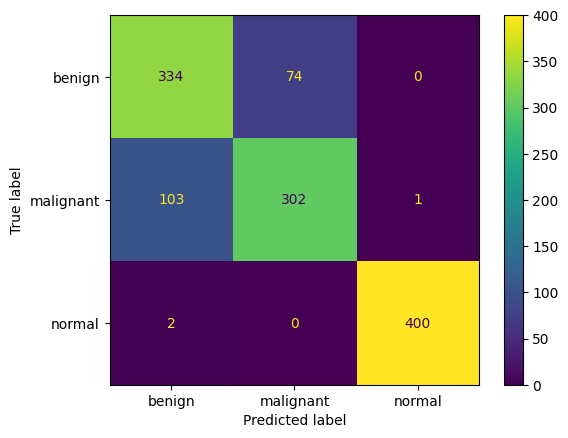

In [ ]:
# evaluate our model against our test dataset
model3.eval()
all_preds_3 = []
all_labels_3 = []

with torch.no_grad():
    for images, labels in test_loader:
       # send labels and images to GPU
        images = images.to(device)
        labels = labels.to(device)

        outputs = model3(images)


        _, predicted = torch.max(outputs, 1)
# convert to numpy and use cpu
        all_preds_3.extend(predicted.cpu().numpy())
        all_labels_3.extend(labels.cpu().numpy())

# use sklearn to evaulate the 3 classess results

print("--------Densenet 169----------\n")
print("Accuracy: ", accuracy_score(all_labels_3, all_preds_3))
print("Balanced Accuracy: ", balanced_accuracy_score(all_labels_3, all_preds_3))
print("Precision", precision_score(all_labels_3, all_preds_3,
                                  average='weighted', zero_division=0))
print("\nClassification Report: \n", classification_report(all_labels_3, all_preds_3,
                                                          zero_division=0,labels=list(range(num_classes))))

cm_3 = confusion_matrix(all_labels_3, all_preds_3, labels=list(range(num_classes)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_3,
                              display_labels=['benign', 'malignant', 'normal'])
disp.plot()
plt.show()


features.conv0 Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
features.denseblock1.denselayer1.conv1 Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
features.denseblock1.denselayer1.conv2 Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
features.denseblock1.denselayer2.conv1 Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
features.denseblock1.denselayer2.conv2 Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
features.denseblock1.denselayer3.conv1 Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
features.denseblock1.denselayer3.conv2 Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
features.denseblock1.denselayer4.conv1 Conv2d(160, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
features.denseblock1.denselayer4.conv2 Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
features.denseblock1.dense

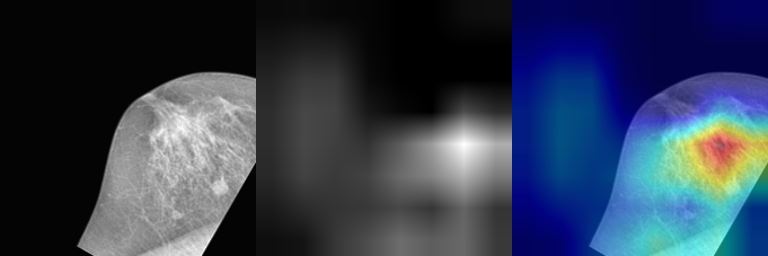

In [ ]:
# function that will select one image for a class
def get_one_image_from_class(directory, class_label):
    dset = FastTensorDataset(directory)
    for img, label in dset:
        if label == class_label:
            return img
    return None

model3.eval()

# select the image
img = get_one_image_from_class("processed_3class", 1)
img = img.unsqueeze(0) # add new dimension to image
img = img.to(device) # add to GPU

# function finds last conv layer any model
def find_last_conv(model):
    last_conv = None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
    return last_conv

# finds the layer
layer = find_last_conv(model3)

# Prepare the original image for show_cam_on_image
original_img_for_cam_display = img.squeeze(0).permute(1, 2, 0).cpu().numpy()
original_img_for_cam_display = (original_img_for_cam_display - original_img_for_cam_display.min()) / \
                               (original_img_for_cam_display.max() - original_img_for_cam_display.min() + 1e-6)

with GradCAM(model=model3, target_layers=[layer]) as cam:
    grayscale_cams = cam(input_tensor=img, targets=[ClassifierOutputTarget(2)])
    # Pass the correctly shaped and normalized image to show_cam_on_image, this is the grad-cam image
    cam_image = show_cam_on_image(original_img_for_cam_display, grayscale_cams[0, :], use_rgb=True)

cam_processed = np.uint8(255*grayscale_cams[0, :])
cam_processed = cv2.merge([cam_processed, cam_processed, cam_processed])

# Normalize img for display if not already in [0, 1] range (for hstack)
img_display = img.squeeze().permute(1, 2, 0).cpu().numpy()
img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-6)
img_display = np.uint8(255 * img_display)

images = np.hstack((img_display, cam_processed , cam_image))
Image.fromarray(images)